# 투구 제구 성공 확률 예측 - 탐색용 노트북

이 노트북은 `train_ensemble.py`의 로직을 셀 단위로 쪼개서
- 데이터가 예상한 형태인지
- 트랙맨 매칭률이 실제로 얼마나 나오는지
- 모델 하나만 먼저 돌렸을 때 Brier가 어느 정도인지
- 보정(calibration) 전/후 점수 차이가 실제로 있는지

를 눈으로 확인하기 위한 용도입니다. 여기서 검증이 끝나면
동일 디렉토리의 `train_ensemble.py` / `script.py`로 옮겨 제출 규격에 맞춥니다.

> 이 파일과 `train_ensemble.py`는 같은 폴더에 있어야 아래 import가 동작합니다.

In [5]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

sys.path.append(os.getcwd())
from train_ensemble import (
    ID_COL, TARGET_COL, CAT_COLS,
    build_trackman_pitcher_prior, attach_trackman_prior, build_features,
    train_lgb, train_xgb, train_cat,
)

DATA_DIR = "../open/data"  # train.csv, trackman_history.csv 위치로 수정

## 1. 데이터 로드 & 기본 확인

가장 먼저 확인할 것:
- 행/컬럼 수가 설명서(1,475,092행 x 49컬럼)와 일치하는지
- `control_success` 비율(r)이 어느 정도인지 → 베이스라인 Brier(r(1-r))를 직접 계산해볼 수 있음

In [6]:
train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"), encoding="utf-8-sig")
print(train.shape)
train.head()

(1475092, 49)


,row_id,season,game_month,game_dayofweek,inning,top_bottom,game_type,balls_before,strikes_before,outs_before,...,asof_pitcher_prev3_game_middle_rate,asof_pitcher_prev5_game_middle_rate,asof_batter_n,asof_batter_success_rate,asof_batter_middle_rate,asof_pitcher_pitchmix_n,asof_pitcher_fastball_rate,asof_pitcher_breaking_rate,asof_pitcher_offspeed_rate,control_success
0,TRAIN_0000001,2019,3,5,1,T,R,0,0,0,...,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,0
1,TRAIN_0000002,2019,3,5,1,T,R,0,0,0,...,NaN,NaN,0,NaN,NaN,1,1.0,0.0,0.0,0
2,TRAIN_0000003,2019,3,5,1,T,R,1,0,0,...,NaN,NaN,1,0.0,0.0,2,1.0,0.0,0.0,0
3,TRAIN_0000004,2019,3,5,1,T,R,0,0,2,...,NaN,NaN,0,NaN,NaN,3,1.0,0.0,0.0,1
4,TRAIN_0000005,2019,3,5,1,T,R,0,1,2,...,NaN,NaN,1,1.0,0.0,4,1.0,0.0,0.0,1


In [33]:
train['pitcher_id'].describe()

count    1.475092e+06
mean     2.326594e+04
std      8.003636e+02
min      2.070000e+04
25%      2.265100e+04
50%      2.347800e+04
75%      2.388000e+04
max      2.463300e+04
Name: pitcher_id, dtype: float64

In [35]:
trackman_history = pd.read_csv(os.path.join(DATA_DIR, "trackman_history.csv"), encoding="utf-8-sig")
# print(trackman_history.shape)
trackman_history['pitcher_trackman_id'].describe()

count    1.793078e+06
mean     1.463249e+05
std      7.253059e+05
min      5.000800e+04
25%      6.126800e+04
50%      6.660900e+04
75%      7.042500e+04
max      7.177516e+07
Name: pitcher_trackman_id, dtype: float64

In [7]:
r = train[TARGET_COL].mean()
baseline_brier = r * (1 - r)
print(f"제구 성공률 r = {r:.4f}")
print(f"기준(무정보) Brier = {baseline_brier:.5f}  <- 이거보다 낮게 만들어야 Score>0")

제구 성공률 r = 0.5238
기준(무정보) Brier = 0.24944  <- 이거보다 낮게 만들어야 Score>0


In [21]:
train.isna().mean().sort_values(ascending=False).head(20)  # 컬럼별 결측률 확인

asof_pitcher_prev5_game_success_rate    0.019785
asof_pitcher_prev3_game_middle_rate     0.019785
asof_pitcher_prev1_game_success_rate    0.019785
asof_pitcher_prev3_game_success_rate    0.019785
asof_pitcher_prev1_game_middle_rate     0.019785
asof_pitcher_prev5_game_middle_rate     0.019785
asof_batter_middle_rate                 0.000563
asof_batter_success_rate                0.000563
asof_pitcher_success_rate               0.000537
asof_pitcher_fastball_rate              0.000537
asof_pitcher_breaking_rate              0.000537
asof_pitcher_offspeed_rate              0.000537
asof_pitcher_strike_rate                0.000537
asof_pitcher_ball_rate                  0.000537
asof_pitcher_middle_rate                0.000537
asof_pitcher_reverse_rate               0.000537
batter_team_id                          0.000000
pitcher_team_id                         0.000000
asof_pitcher_n                          0.000000
row_id                                  0.000000
dtype: float64

## 2. 트랙맨 매칭률 확인 (중요)

`pitcher_id`와 `pitcher_trackman_id`가 같은 익명화 공간인지 실제로 확인.
매칭률이 너무 낮으면(예: <5%) 트랙맨 prior는 이번 라운드에서는 빼고
`asof_*` 컬럼만으로 먼저 베이스라인을 잡는 게 낫습니다.

In [9]:
trackman_path = os.path.join(DATA_DIR, "trackman_history.csv")
prior_table = None
if os.path.exists(trackman_path):
    prior_table = build_trackman_pitcher_prior(trackman_path)
    print(prior_table.shape)
    display(prior_table.head())

    tmp = train[["pitcher_id"]].merge(prior_table[["pitcher_id"]].drop_duplicates(),
                                        on="pitcher_id", how="left", indicator=True)
    match_rate = (tmp["_merge"] == "both").mean()
    print(f"train 기준 pitcher_id 매칭률: {match_rate:.1%}")
else:
    print("trackman_history.csv가 없습니다. asof_* 컬럼만으로 진행합니다.")

(906, 11)


,pitcher_id,tm_n,tm_rel_speed_mean,tm_spin_rate_mean,tm_ivb_mean,tm_hb_mean,tm_extension_mean,tm_mix_breaking,tm_mix_fastball,tm_mix_offspeed,tm_mix_other
0,50008,30,133.413767,2215.786333,27.113480,-8.038093,1.474019,0.300000,0.700000,0.000000,0.000000
1,50010,986,131.357377,2118.265219,33.968337,13.478821,1.789900,0.365112,0.530426,0.098377,0.006085
2,50030,7449,137.945706,2025.213418,16.779461,20.716356,1.878885,0.149416,0.594845,0.250906,0.004833
3,50036,2246,141.768521,2240.995336,2.657223,33.136029,1.778326,0.178985,0.753339,0.062333,0.005343
4,50094,301,133.295620,2081.299667,34.780670,4.029097,1.787843,0.265781,0.644518,0.086379,0.003322


train 기준 pitcher_id 매칭률: 0.0%


## 3. 피처 엔지니어링 확인

`build_features`가 만든 컬럼 목록과, 카테고리/수치형이 의도대로 처리됐는지 확인.
매칭률이 낮았다면 아래에서 `trackman_prior=None`으로 바꿔서 진행하세요.

In [36]:
USE_TRACKMAN = False  # 위에서 매칭률 확인 후 False로 바꿔도 됨

train_feat, feat_cols = build_features(
    train, prior_table if USE_TRACKMAN else None
)
cat_features = [c for c in CAT_COLS if c in feat_cols]

print(f"피처 개수: {len(feat_cols)}")
print(f"범주형: {cat_features}")
train_feat[feat_cols].dtypes.value_counts()

피처 개수: 69
범주형: ['top_bottom', 'game_type', 'base_state', 'pitcher_hand', 'batter_hand']


int64       24
float64     22
int8        18
category     2
category     1
category     1
category     1
Name: count, dtype: int64

## 4. 빠른 베이스라인: LightGBM 1개만 먼저 (전체 앙상블 전에 감 잡기)

풀 데이터로 5-fold 다 돌리면 시간이 걸리니, 먼저 **일부 샘플 + 폴드 축소**로
파이프라인이 끝까지 도는지, Brier가 합리적인지부터 빠르게 확인합니다.

In [37]:
SAMPLE_N = 200_000  # 우선 20만 행 정도로 빠르게 확인 (전체 147만행은 이후)

sample_idx = train_feat.sample(n=min(SAMPLE_N, len(train_feat)), random_state=42).index
X_small = train_feat.loc[sample_idx, feat_cols]
y_small = train_feat.loc[sample_idx, TARGET_COL].values

# train_lgb 내부는 5-fold 기본값 -> 빠른 확인 목적이면 함수 내부의 n_folds를 2~3으로
# 잠깐 바꿔 쓰거나, 아래처럼 그대로 5-fold 돌려도 20만행이면 수 분 내로 끝남
lgb_models, lgb_oof = train_lgb(X_small, y_small, X_small, cat_features)
print(f"LightGBM 단일모델 OOF Brier (표본 {SAMPLE_N}행): {brier_score_loss(y_small, lgb_oof):.5f}")
print(f"참고 - 기준 Brier: {baseline_brier:.5f}")

  [LGB fold 0] brier=0.24575
  [LGB fold 1] brier=0.24576
  [LGB fold 2] brier=0.24511
  [LGB fold 3] brier=0.24587
  [LGB fold 4] brier=0.24585
LightGBM 단일모델 OOF Brier (표본 200000행): 0.24567
참고 - 기준 Brier: 0.24944


## 5. 보정(calibration) 전/후 비교 — 왜 필요한지 눈으로 확인

Reliability diagram(신뢰도 곡선)을 그려서, 모델이 뱉은 확률이
실제 발생 빈도와 얼마나 어긋나는지 확인합니다. 대각선에 가까울수록 잘 보정된 것.

보정 전 Brier: 0.24567
보정 후 Brier: 0.24555


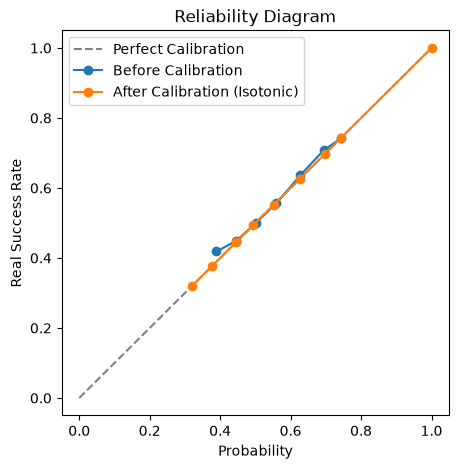

In [38]:
from sklearn.isotonic import IsotonicRegression

iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(lgb_oof, y_small)
lgb_oof_cal = iso.predict(lgb_oof)

print(f"보정 전 Brier: {brier_score_loss(y_small, lgb_oof):.5f}")
print(f"보정 후 Brier: {brier_score_loss(y_small, lgb_oof_cal):.5f}")

frac_pos_raw, mean_pred_raw = calibration_curve(y_small, lgb_oof, n_bins=15)
frac_pos_cal, mean_pred_cal = calibration_curve(y_small, lgb_oof_cal, n_bins=15)

plt.figure(figsize=(5,5))
plt.plot([0,1],[0,1], linestyle="--", color="gray", label="Perfect Calibration")
plt.plot(mean_pred_raw, frac_pos_raw, marker="o", label="Before Calibration")
plt.plot(mean_pred_cal, frac_pos_cal, marker="o", label="After Calibration (Isotonic)")
plt.xlabel("Probability"); plt.ylabel("Real Success Rate")
plt.legend(); plt.title("Reliability Diagram")
plt.show()

## 6. 여기까지 확인됐다면 다음 단계

- [ ] 트랙맨 매칭률이 쓸만한지 결론 내리기 (3번 셀 결과 기준)
- [ ] LightGBM 단일 모델 OOF Brier가 기준 Brier보다 확실히 낮은지 확인 (4번 셀)
- [ ] 보정 후 Brier가 실제로 개선되는지 확인 (5번 셀) — Score 계산식상 이게 등수에 직결
- [ ] 전체 147만행 + 5-fold + XGBoost/CatBoost까지 확장
- [ ] 여기서 검증된 로직을 `train_ensemble.py`에 그대로 반영 (이미 동일 함수 구조이므로 옮기기 쉬움)
- [ ] 최종적으로 `train_ensemble.py` 실행 → `model/ensemble_bundle.pkl` → `script.py`로 제출 규격 구성

궁금한 부분이나 이상한 결과가 나오면 셀 결과를 공유해주시면 같이 원인을 봐드릴게요.